# Deep Operator Network

Deep Operator Networks (DeepONets) learn the operator that maps a set of functions to another function. Using the same PDE as the [PINN](pinn.ipynb) and [P$^2$INN](parametrized_pinn.ipynb) examples, we will learn the mapping $G: \{N(t), g_0(x)\} \rightarrow g(x,t)$, where $N(t)$ is the relative population size change and $g_0$ is the initial condition of the PDE. Our model's coordinate inputs will be $(x,t)$, as before, and the auxiliary inputs will be arrays of $N(t)$ and $g_0(x)$ evaluated at fixed $t_s$ and $x_s$ sensor points. 

As before, we will enforce $N(t = 0) = 1$ and choose a linear population size change function, $N(t| N_s) = N_s t + 1$.  We will evaluate $N(t| N_s)$ for different $N_s$ values and across a fixed set of sensor points $t_s$. The resulting array will have a shape `(NUM_NS_PTS, NUM_TS_PTS)`. 

Because $N(t = 0) = 1$, the initial condtion 

$$
g_0(x) = \theta\frac{1 - e^{-2\gamma(1-x)}}{1 - e^{-2\gamma}}
$$

only depends on $\gamma$, so we can construct our training data by varying $\gamma$ and evaluating $g_0(x| \gamma)$ across a fixed set of sensor points $x_s$. The resulting data array will have a shape `(NUM_G_PTS, NUM_XS_PTS)`.

In [13]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

import jax

jax.config.update("jax_enable_x64", True)

import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jaxtyping import Array

from popinn import AdamConfig, LBFGSConfig, Loss, ResidualTerm, plot_training_history, train_model, warmup_cosine

In [14]:
# Fixed values

THETA = 1.0  # population-scaled mutation rate
NFUNC = lambda t, N_s: N_s * t + 1.0  # linear population size increase

# gamma bounds
GMIN = 0.01
GMAX = 5.0

# gamma grid length
NUM_G_PTS = 30
NUM_XS_PTS = 31

# N_s bounds:
NS_MIN = 1.0
NS_MAX = 10.0

# N_s grid length
NUM_NS_PTS = 30
NUM_TS_PTS = 30

# x-coordinate bounds
XMIN = 0.0
XMAX = 1.0

# t-coordinate maximum
TMAX = 1.0

# colocation grid lengths
NUM_PDE_PTS = 30  # points per spatial/temporal coordinate axis on PDE interior
NUM_EDGE_PTS = 256  # points used to sample the IC/boundary coordinate lines

## Residual Terms

In this example, $N(t|N_s)$ and $g_0(x| \gamma)$ are the auxiliary inputs of our model. Like in the [P$^2$INN](parametrized_pinn.ipynb) example, there are residual equations that will also need the value of $\gamma$ and/or $N_s$, e.g. the PDE:

$$
\frac{\partial g}{\partial t} = \frac{1}{2N(t|N_s)}x (1 - x)\frac{\partial^2 g}{\partial x^2}- \gamma x (1 - x)\frac{\partial g}{\partial x}.
$$

We therefore must pass $\gamma$ and $N_s$ through the `aux` argument of our residual functions, but only pass $N(t|N_s)$ and $g_0(x| \gamma)$ as the `aux` argument of the model. Since we'll be unpacking `aux` for each residual term, we'll define a convenience function to do it for us:

In [15]:
def unpack(aux):
    (Nvals_, Ns_), (ics_, gamma_) = aux
    return (Nvals_, ics_), Ns_, gamma_  # group the model inputs together in a tuple

We'll wait until the Training Data section to explain how to structure `aux`. For now, note that `Nvals_` and `ics_` in the above function will each be a 1D array of $N(t|N_s)$ and $g_0(x|\gamma)$ values evaluated at a set of $t_s$ and $x_s$ points for a fixed value of $N_s$ and $\gamma$.

In [16]:
# PDE residual
def pde_residual(model):
    def r(x, t, aux):
        model_aux, Ns, gamma = unpack(aux)  # separate out model aux inputs

        dg_dx = model.D(0)(x, t, model_aux)  # d/dx
        dg_dt = model.D(1)(x, t, model_aux)  # d/dt
        d2g_dx2 = model.D(0, 0)(x, t, model_aux)  # d2/dx2

        diff = x * (1.0 - x) / (2.0 * NFUNC(t, Ns)) * d2g_dx2  # diffusion
        sel = gamma * x * (1.0 - x) * dg_dx  # selection

        # we weight the per-point residuals by their frequency x, as the gradients
        # tend to be very large at low-frequency. Wrapping x in
        # jax.lax.stop_gradient treats it like a constant, rather than a differentiable
        # quantity, so it doesn't change the PDE we are trying to learn
        return (dg_dt + sel - diff) * jax.lax.stop_gradient(x)

    return r

In [17]:
# Left BC residual
def left_bc_residual(model):
    def r(x, t, aux):
        model_aux, Ns, gamma = unpack(aux)
        return model(x, t, model_aux) - THETA * NFUNC(t, Ns)

    return r

In [18]:
# Right BC residual
def right_bc_residual(model):
    def r(x, t, aux):
        model_aux, Ns, gamma = unpack(aux)
        return model(x, t, model_aux)

    return r

In [19]:
def initial_g(x, _gamma):
    neutral = 1.0 - x
    selected = jnp.expm1(-2.0 * _gamma * (1.0 - x)) / jnp.expm1(-2.0 * _gamma)
    # jnp.where keeps this differentiable and vmap-friendly across gamma.
    return THETA * jnp.where(jnp.greater(jnp.abs(_gamma), 1e-5), selected, neutral)


# initial condition residual
def ic_residual(model):
    def r(x, t, aux):
        model_aux, Ns, gamma = unpack(aux)
        return model(x, t, model_aux) - initial_g(x, gamma)

    return r

The `Loss` initialization stays the same:

In [20]:
total_loss = Loss(
    [
        ResidualTerm(name="pde", residual_fn=pde_residual),
        ResidualTerm(name="left_bc", residual_fn=left_bc_residual),
        ResidualTerm(name="right_bc", residual_fn=right_bc_residual),
        ResidualTerm(name="ic", residual_fn=ic_residual),
    ]
)

## Training Data

Now we need to evaluate the input functions for different parameter values and across fixed sensor points. We'll use a function that gives us exponentially spaced data for the interior PDE collocation points and sensor points.

In [21]:
def exponential_grid(pts, crwd=8, where="both"):
    """
    This function was adapted from `exponential_grid` in the dadi package (https://github.com/RyanGutenkunst/dadi/blob/32d6a6003675a7b015149f3e04d06bafe3908de1/dadi/Numerics.py#L215-L231).
    - An exponentially spaced grid.
    - crwd controls the degree to which grid points crowd against x=0 or x=1.
    - where: 'both' or 'left' or 'right'

    """
    if where == "both":
        xlim = (-1.0, 1.0)
    elif where == "left":
        xlim = (-1.0, 0.0)
    elif where == "right":
        xlim = (0.0, 1)
    else:
        raise ValueError("`where` argument can be 'both', 'left', or 'right'.")
    unif = jnp.linspace(*xlim, pts + 1)
    grid = 1.0 / (1.0 + jnp.exp(-crwd * unif))

    # Normalize
    grid = (grid - grid[0]) / (grid[-1] - grid[0])
    return grid[1:]

In [22]:
class TrainingData(eqx.Module):
    pde_coords: tuple[Array]
    ic_coords: tuple[Array]
    left_bc_coords: tuple[Array]
    right_bc_coords: tuple[Array]
    aux: tuple


X_pde = exponential_grid(NUM_PDE_PTS, crwd=2.0, where="left")
T_pde = jnp.linspace(0, TMAX, NUM_PDE_PTS)

X_ic = jnp.linspace(XMIN, XMAX, NUM_EDGE_PTS)
T_ic = jnp.zeros(1)

T_bc = jnp.linspace(0, TMAX, NUM_EDGE_PTS)
X_lbc = XMIN * jnp.ones(1)
X_rbc = XMAX * jnp.ones(1)

# all of the above code is the same as P2INN
# Get the N(t) array
TS = jnp.linspace(0, TMAX, NUM_TS_PTS)
NS = jnp.linspace(NS_MIN, NS_MAX, NUM_NS_PTS)
NVALS = jax.vmap(NFUNC, in_axes=(None, 0))(TS, NS)  # map over the set of Ns values
assert NVALS.shape == (NUM_NS_PTS, NUM_TS_PTS)

# Get the g_0(x) array
XS = exponential_grid(NUM_XS_PTS, crwd=2.0, where="left")
GAMMA = jnp.linspace(GMIN, GMAX, NUM_G_PTS)
ICVALS = jax.vmap(initial_g, in_axes=(None, 0))(XS, GAMMA)  # map over the set of gamma values
assert ICVALS.shape == (NUM_G_PTS, NUM_XS_PTS)

data = TrainingData(
    pde_coords=(X_pde, T_pde),
    ic_coords=(X_ic, T_ic),
    left_bc_coords=(X_lbc, T_bc),
    right_bc_coords=(X_rbc, T_bc),
    aux=((NVALS, NS), (ICVALS, GAMMA)),  # construct the aux tuple, packaging correlated quantities that share their 0th axis in their own tuple
)

!!! Example "Important syntax note"
    The the grid evaluation method used by `ResidualTerm` expects `aux` to be packaged in a specific way in order to properly broadcast the training data over the per-point residual function. 

    In this example, the proper packaging is

    ```python
    aux = ((NVALS, NS), (ICVALS, GAMMA))
    ```

    Notice that 1D `NS` array was used to calculate the 2D `NVALS` array and their 0th axis has the same length. The same goes for `GAMMA` and `ICVALS`. Even though the model's auxiliary inputs are only `NVALS` and `ICVALS`, the residual functions we defined above require `NS` and `GAMMA` as additional auxiliary inputs. To ensure the individual parameter values are passed to the residual function alongside their corresponding function values, we can package them together in a tuple in `aux`. This will signal to `eval_grid` that it should zip their shared 0th axis during the cartesian product. For example, the PDE residual output will have the shape `(NUM_G_PTS, NUM_NS_PTS, NUM_PDE_PTS, NUM_PDE_PTS)` before it applies the metric to reduce it to a scalar. 

    The grid axis should always be the 0th axis of each array; all trailing axes are assumed to be per-point inputs. This is why we included the assertions above that check `ICVALS.shape == (NUM_G_PTS, NUM_XS_PTS)` and `NVALS.shape == (NUM_NS_PTS, NUM_TS_PTS)`.

## Initialize Model and Train

We'll first train with 1000 Adam steps, then 10k of L-BFGS:

In [23]:
key = jr.PRNGKey(3)
from popinn import DeepONet

model = DeepONet(key, branch_input_dim=(NUM_TS_PTS, NUM_XS_PTS), trunk_input_dim=2, branch_depth=(4, 4), trunk_depth=2)


model, history = train_model(
    model,
    data,
    total_loss,
    [AdamConfig(log_every=500, num_epochs=1000, lr=warmup_cosine(peak_lr=5e-4, num_epochs=1000)), LBFGSConfig(log_every=500, num_epochs=10000)],
)

[Adam] Starting (1000 epochs)
[Adam] Epoch      1 | total: 2.68e+01 | ic: 2.07e+00  left_bc: 2.43e+01  pde: 2.94e-06  right_bc: 4.12e-01
[Adam] Epoch    500 | total: 4.08e-01 | ic: 5.29e-02  left_bc: 3.01e-02  pde: 3.06e-01  right_bc: 1.89e-02
[Adam] Epoch   1000 | total: 2.21e-01 | ic: 2.94e-02  left_bc: 2.21e-02  pde: 1.55e-01  right_bc: 1.44e-02
[L-BFGS] Starting (10000 max iterations)
[L-BFGS] Step      1 | total: 2.21e-01 | ic: 2.89e-02  left_bc: 2.19e-02  pde: 1.56e-01  right_bc: 1.36e-02
[L-BFGS] Step    500 | total: 5.89e-02 | ic: 1.35e-02  left_bc: 3.22e-03  pde: 3.62e-02  right_bc: 6.03e-03
[L-BFGS] Step   1000 | total: 3.71e-02 | ic: 9.63e-03  left_bc: 1.11e-03  pde: 2.10e-02  right_bc: 5.34e-03
[L-BFGS] Step   1500 | total: 1.77e-02 | ic: 2.61e-03  left_bc: 1.08e-03  pde: 1.22e-02  right_bc: 1.74e-03
[L-BFGS] Step   2000 | total: 7.75e-03 | ic: 8.86e-04  left_bc: 4.79e-04  pde: 6.05e-03  right_bc: 3.37e-04
[L-BFGS] Step   2500 | total: 4.77e-03 | ic: 5.12e-04  left_bc: 3.06

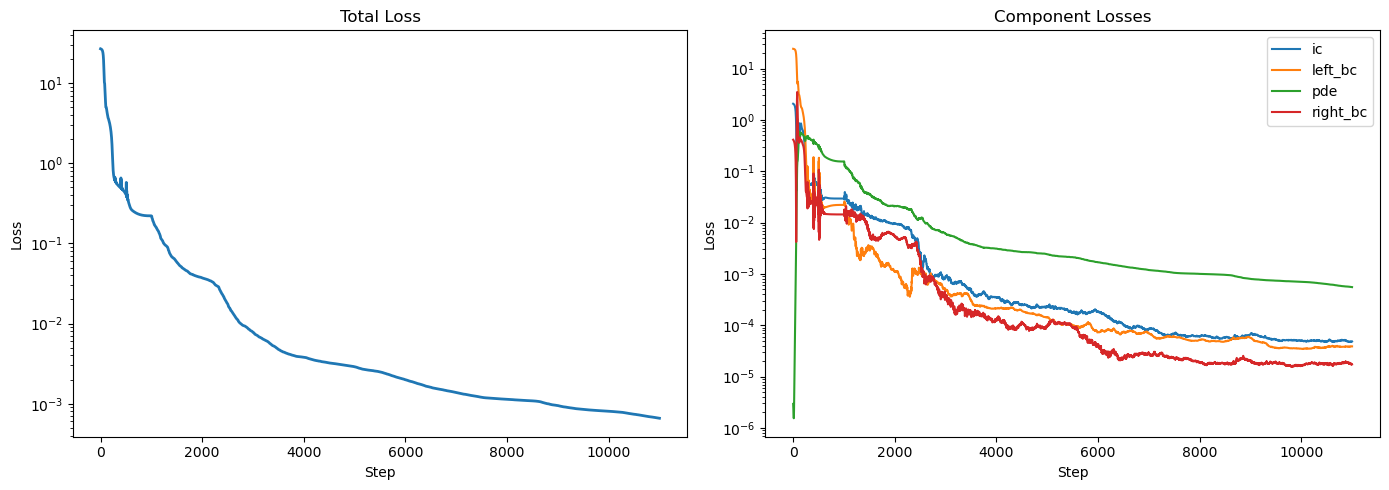

In [24]:
plot_training_history(history)

We'll check our trained solution at $t = 1$ against a numerical solver, specifically the solver included in the [`dadi`](https://github.com/RyanGutenkunst/dadi) package. `dadi` works in the untransformed frequency $\phi(x,t)$, so we'll need to multiply it by $x(1-x)$ to convert it to $g(x,t)$

In [25]:
import dadi

TEST_GAMMA = 2.0
TEST_IC = initial_g(XS, TEST_GAMMA)
TEST_NS = 3.0
TEST_NVALS = NFUNC(TS, TEST_NS)


def calc_dadi(tf=1.0, pts=300):
    xx = dadi.Numerics.default_grid(pts=pts)
    phi0 = dadi.PhiManip.phi_1D(xx, gamma=TEST_GAMMA)
    phif = dadi.Integration.one_pop(phi0, xx, tf, lambda t: NFUNC(t, TEST_NS), gamma=TEST_GAMMA)
    return xx, phif, phi0

In [ ]:
x_dadi, phi_dadi, phi0_dadi = calc_dadi()
x_test = jnp.linspace(0, 1, 100)
g_test = jax.vmap(model, in_axes=(0, None, None))(x_test, 1.0, (TEST_NVALS, TEST_IC))

Text(0.5, 1.0, '1k Adam, 11k LBFGS $\\gamma =$ 2.0, $N_b =$ 3.0')

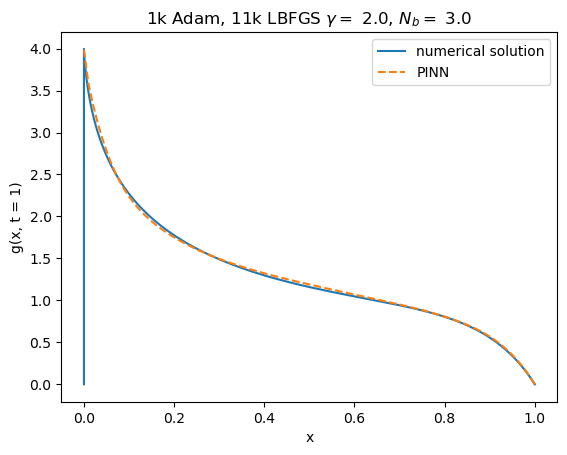

In [ ]:
# plt.figure(figsize=(5, 4))
plt.plot(x_dadi, phi_dadi * x_dadi * (1.0 - x_dadi), label="numerical solution")  # convert phi to g
plt.plot(x_test, g_test, label="PINN", ls="--")
plt.legend()
plt.xlabel("x")
plt.ylabel("g(x, t = 1)")
# plt.tight_layout()
plt.title(rf"1k Adam, 11k LBFGS $\gamma =$ {TEST_GAMMA}, $N_b =$ {TEST_NS}")